In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from collections import Counter
import re

data = pd.read_pickle('../data/processed/data_with_pdf_text.pkl')
print(data.shape)
print(data['User type'].value_counts())

(1216, 74)
User type
Company/Business organisation          150
NGO (Non-governmental organisation)    117
EU Citizen                             115
Academic/Research Institution          112
Business Association                   111
Other                                   62
Public authority                        43
Trade Union                             21
Non-EU Citizen                          17
Consumer Organisation                    7
Environmental Organisation               1
Name: count, dtype: int64


In [2]:
# Identify the main free-text columns from the survey
text_cols = [
    'Are there other actions that should be considered?\n',
    'Do you have any further considerations regarding the question above?',
    'What is the best way to ensure that AI is trustworthy, secure and in respect of European values and rules?',
]

def combine_text(row):
    if pd.notna(row['pdf_text']):
        return row['pdf_text']
    # Fall back to concatenating free text survey answers
    parts = [str(row[c]) for c in text_cols if pd.notna(row[c])]
    return ' '.join(parts) if parts else None

data['full_text'] = data.apply(combine_text, axis=1)
print(f"Rows with usable text: {data['full_text'].notna().sum()}")

Rows with usable text: 1150


In [3]:
# Define keywords to track
keywords = ['innovation', 'fundamental rights', 'liability', 'transparency', 
            'human oversight', 'data', 'risk', 'trust', 'regulation', 'ethics']

def count_keywords(text, keywords):
    if pd.isna(text):
        return {k: 0 for k in keywords}
    text = text.lower()
    return {k: len(re.findall(r'\b' + k + r'\b', text)) for k in keywords}

# Apply to all rows
kw_counts = data['full_text'].apply(lambda t: count_keywords(t, keywords))
kw_df = pd.DataFrame(kw_counts.tolist())
kw_df['User type'] = data['User type'].values

# Average keyword frequency per actor type
result = kw_df.groupby('User type')[keywords].mean()
print(result.round(2))

                                     innovation  fundamental rights  \
User type                                                             
Academic/Research Institution              2.59                1.07   
Business Association                       2.70                0.53   
Company/Business organisation              2.54                0.61   
Consumer Organisation                      0.14                0.00   
EU Citizen                                 0.39                0.21   
Environmental Organisation                 1.00                0.00   
NGO (Non-governmental organisation)        2.50                2.93   
Non-EU Citizen                             0.47                0.35   
Other                                      2.63                1.08   
Public authority                           0.74                0.30   
Trade Union                                0.38                0.14   

                                     liability  transparency  human oversigh

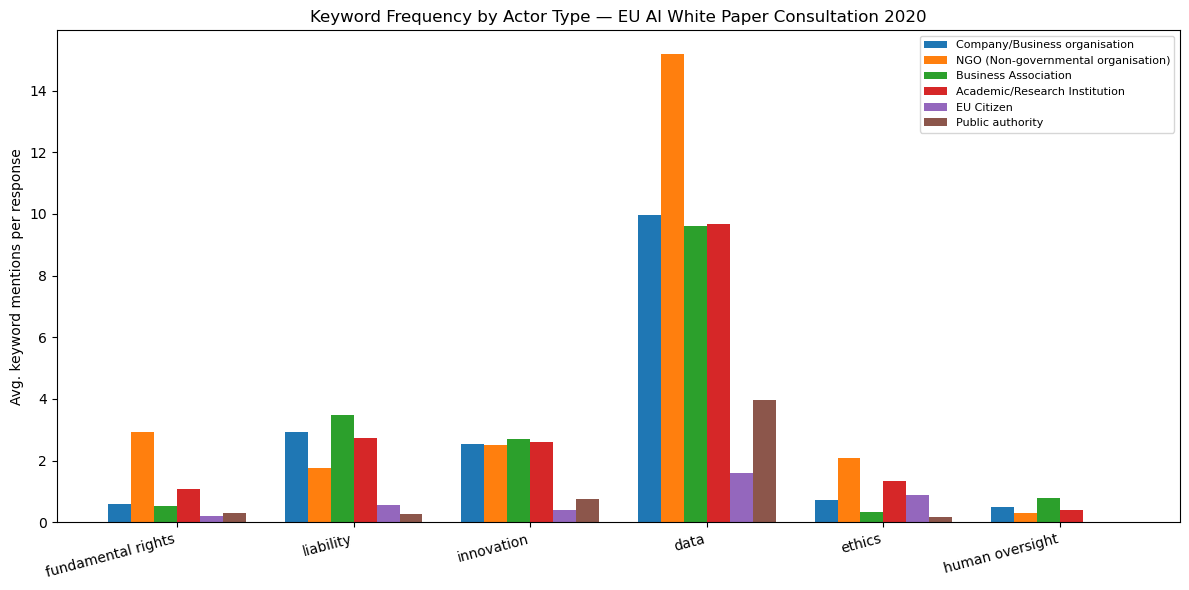

In [4]:
import numpy as np

plot_keywords = ['fundamental rights', 'liability', 'innovation', 'data', 'ethics', 'human oversight']

main_actors = ['Company/Business organisation', 'NGO (Non-governmental organisation)', 
               'Business Association', 'Academic/Research Institution', 'EU Citizen', 'Public authority']

plot_data = result.loc[main_actors, plot_keywords]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_keywords))
width = 0.13

for i, actor in enumerate(main_actors):
    ax.bar(x + i*width, plot_data.loc[actor], width, label=actor)

ax.set_xticks(x + width*2.5)
ax.set_xticklabels(plot_keywords, rotation=15, ha='right')
ax.set_ylabel('Avg. keyword mentions per response')
ax.set_title('Keyword Frequency by Actor Type — EU AI White Paper Consultation 2020')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/keyword_by_actor.png', dpi=150)
plt.show()